# 06 · Test design: sizing the retargeting and Display holdouts

Two recommendations rest on effects that this observational data can't measure:

- **D2, retargeting** ([notebook 04](04_analyze_remarketing.ipynb)): the break-even borrows a **10% lift** from published experiments. Only a randomized holdout can measure this store's own lift.
- **D1, Display** ([notebook 05](05_analyze_attribution.ipynb)): attribution can't show whether Display *causes* the purchases GA credits to it.

This notebook sizes both tests from the store's own volumes before anyone runs them: how large an effect each design can detect, and how long it has to run.

**Method** ([`src/power.py`](../src/power.py)): normal approximation, two-sided test at α = 5% with 80% power, so z\* = z₀.₉₇₅ + z₀.₈₀ = 2.80.

- **Per-visitor metrics** (a 30-day purchase or return visit, revenue): with n visitors, a share h held out and a per-visitor standard deviation σ (σ = √(p(1 − p)) for a rate p), the difference between the arms has SE = σ·√(1/((1 − h)n) + 1/(hn)). The smallest relative lift detected with 80% power is **MDE = 2.80 · SE / μ**, and the power at a lift L is Φ(Lμ/SE − 1.96) + Φ(−Lμ/SE − 1.96).
- **Weekly counts** (Display): if every Display-credited purchase were incremental, the holdout would lose D of the store's S purchases a week. Over W weeks the full-scale difference between the arms has variance W · (S/(1 − h) + (S − D)/h) under a Poisson model. Visitors who come back repeatedly add noise, which a variance-inflation factor (VIF) allows for.
- **Duration:** the shortest enrolment at which power reaches 80%.

**Assumptions:** visitors are independent and the arms don't affect each other; the test months' rates (May–June 2017) hold; the analysis is intention to treat (everyone assigned to retargeting counts, whether an ad reached them or not; if only a share r is reached, the lift detectable among them is MDE ÷ r); results are read 30 days after enrolment closes.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from src import viz
from src.breakeven import CENTRAL, REVENUE_CAP_USD, breakeven_lift, value_of_targets
from src.modeling import LABEL, PIPELINES, add_features
from src.power import (duration_for_power, poisson_mde, poisson_power, proportion_sd, two_sample_mde,
                       two_sample_power, z_star)
from src.segments import is_key_account
from src.tables import remarketing_table

# scikit-learn warns when the test months contain categories unseen in training (handled as "infrequent")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

LIFT = 0.10   # the lift notebook 04's break-even assumes
DURATIONS = {"6_weeks": 42 / 30.4, "3_months": 3.0, "6_months": 6.0, "12_months": 12.0}   # months of enrolment
sessions = pd.read_parquet(ROOT / "data/raw/sessions_clean.parquet")
print(f"z* = {z_star():.4f}")

z* = 2.8016


## 1. Retargeting holdout (D2)

**Who is randomized:** first-time visitors who score into the audience, assigned when they're scored and before any ad is served. The inputs therefore come from the population a live campaign would score (notebook 04, section 9): the table without hindsight, with the chosen model refit on it. Staff, the Google employees whom only a later visit reveals, can't be removed at scoring time. They can be left out of the analysis, though: being staff is fixed before assignment, so dropping them afterwards doesn't bias the comparison.

In [2]:
live = add_features(remarketing_table(sessions, internal_flag="first_visit"))
train, test = live[live.split == "train"], live[live.split == "test"]
tuning = pd.read_json(ROOT / "data/processed/tuning_results.json")
chosen = tuning.loc[tuning.cv_pr_auc.idxmax()]   # notebook 04's model: the best validation PR-AUC (gradient boosting)
score = PIPELINES[chosen.model](**chosen.params).fit(train, train[LABEL]).predict_proba(test)[:, 1]
months = (test.session_date.max() - test.session_date.min()).days / 30.4
order = np.argsort(-score, kind="stable")

rows = []
for frac in (0.10, 0.20):
    audience = test.iloc[order[: int(round(frac * len(test)))]]
    analysed = audience[~audience.is_internal]   # staff are dropped at analysis
    revenue = np.minimum(analysed.revenue_30d_usd, REVENUE_CAP_USD)
    rows.append({"audience": f"top {frac:.0%}", "visitors_per_month": len(audience) / months,
                 "staff_share": audience.is_internal.mean(), "analysed_per_month": len(analysed) / months,
                 "purchase_rate": analysed[LABEL].mean(), "return_visit_rate": (analysed.return_visits_30d > 0).mean(),
                 "revenue_per_visitor": revenue.mean(), "revenue_sd": revenue.std()})
inputs = pd.DataFrame(rows).set_index("audience")
inputs.style.format({"visitors_per_month": "{:,.0f}", "staff_share": "{:.1%}", "analysed_per_month": "{:,.0f}",
                     "purchase_rate": "{:.2%}", "return_visit_rate": "{:.1%}", "revenue_per_visitor": "${:.2f}",
                     "revenue_sd": "${:.2f}"})

,visitors_per_month,staff_share,analysed_per_month,purchase_rate,return_visit_rate,revenue_per_visitor,revenue_sd
audience,,,,,,,
top 10%,"4,584",3.7%,"4,414",2.57%,22.7%,$3.43,$41.49
top 20%,"9,167",2.4%,"8,947",1.50%,18.9%,$2.15,$36.90


The design randomizes the **top 20%**. Its purchase rate is lower than the top 10%'s (1.50% against 2.57%), but it doubles enrolment and brings about a fifth more buyers a month, so it detects smaller lifts (the line under the table compares them). Three candidate metrics, each measured per assigned visitor over the 30 days after assignment, under two splits: the 10% holdout first proposed (10/90) and an even split (50/50). The table gives the power to detect a +10% lift after 6 weeks to 12 months of enrolment, the smallest lift detectable at 12 months, and the enrolment needed for 80% power at +10%.

In [3]:
top20 = inputs.loc["top 20%"]
per_month = top20.analysed_per_month
metrics = {"30-day purchase rate": (top20.purchase_rate, proportion_sd(top20.purchase_rate)),
           "30-day return-visit rate": (top20.return_visit_rate, proportion_sd(top20.return_visit_rate)),
           "capped 30-day revenue": (top20.revenue_per_visitor, top20.revenue_sd)}
rows = []
for metric, (mean, sd) in metrics.items():
    for split, holdout in [("50/50", 0.5), ("10/90", 0.1)]:
        row = {"metric": metric, "split": split}
        for name, m in DURATIONS.items():
            row[f"power_{name}"] = two_sample_power(mean, sd, LIFT, per_month * m, holdout)
        row["mde_12_months"] = two_sample_mde(mean, sd, per_month * 12, holdout)
        row["months_for_80pct"] = duration_for_power(lambda m: two_sample_power(mean, sd, LIFT, per_month * m, holdout))
        rows.append(row)
retargeting = pd.DataFrame(rows).set_index(["metric", "split"])
top10 = inputs.loc["top 10%"]
print(f"Top 20%: {per_month * top20.purchase_rate:.0f} later buyers a month analysed. Top 10% instead: "
      f"{top10.analysed_per_month * top10.purchase_rate:.0f} a month, and a 12-month 50/50 MDE for purchases of "
      f"{two_sample_mde(top10.purchase_rate, proportion_sd(top10.purchase_rate), top10.analysed_per_month * 12, 0.5):.1%}")
retargeting.style.format({**{c: "{:.0%}" for c in retargeting.columns if c.startswith("power")},
                          "mde_12_months": "{:.1%}", "months_for_80pct": "{:,.1f}"})

Top 20%: 135 later buyers a month analysed. Top 10% instead: 114 a month, and a 12-month 50/50 MDE for purchases of 15.0%


In [4]:
# The lift a test must detect for retargeting to pay: cost per retargeted visitor / (revenue per visitor x margin).
# Staff are valued at $0: they cost money to reach, but an ad can't make them buy.
revenue_per_visitor = value_of_targets(test[LABEL].to_numpy(), test.revenue_30d_usd.to_numpy(), score, months,
                                       targets=(0.20,), zero_lift=test.is_internal.to_numpy()).revenue_per_visitor[0]
mde = retargeting.loc[("30-day purchase rate", "50/50"), "mde_12_months"]
print(f"Top 20%: capped 30-day revenue ${revenue_per_visitor:.2f} per retargeted visitor (staff at $0). The 12-month "
      f"MDE ({mde:.1%}) is the break-even lift at ${mde * revenue_per_visitor * CENTRAL['margin']:.3f} per retargeted visitor.")
costs = [0.05, 0.10, 0.15, 0.20]
pd.DataFrame({"cost_per_retargeted_visitor": costs, "breakeven_lift": breakeven_lift(costs, revenue_per_visitor)}) \
    .style.format({"cost_per_retargeted_visitor": "${:.2f}", "breakeven_lift": "{:.1%}"}).hide(axis="index")

Top 20%: capped 30-day revenue $2.10 per retargeted visitor (staff at $0). The 12-month MDE (13.8%) is the break-even lift at $0.145 per retargeted visitor.


cost_per_retargeted_visitor,breakeven_lift
$0.05,4.8%
$0.10,9.5%
$0.15,14.3%
$0.20,19.0%


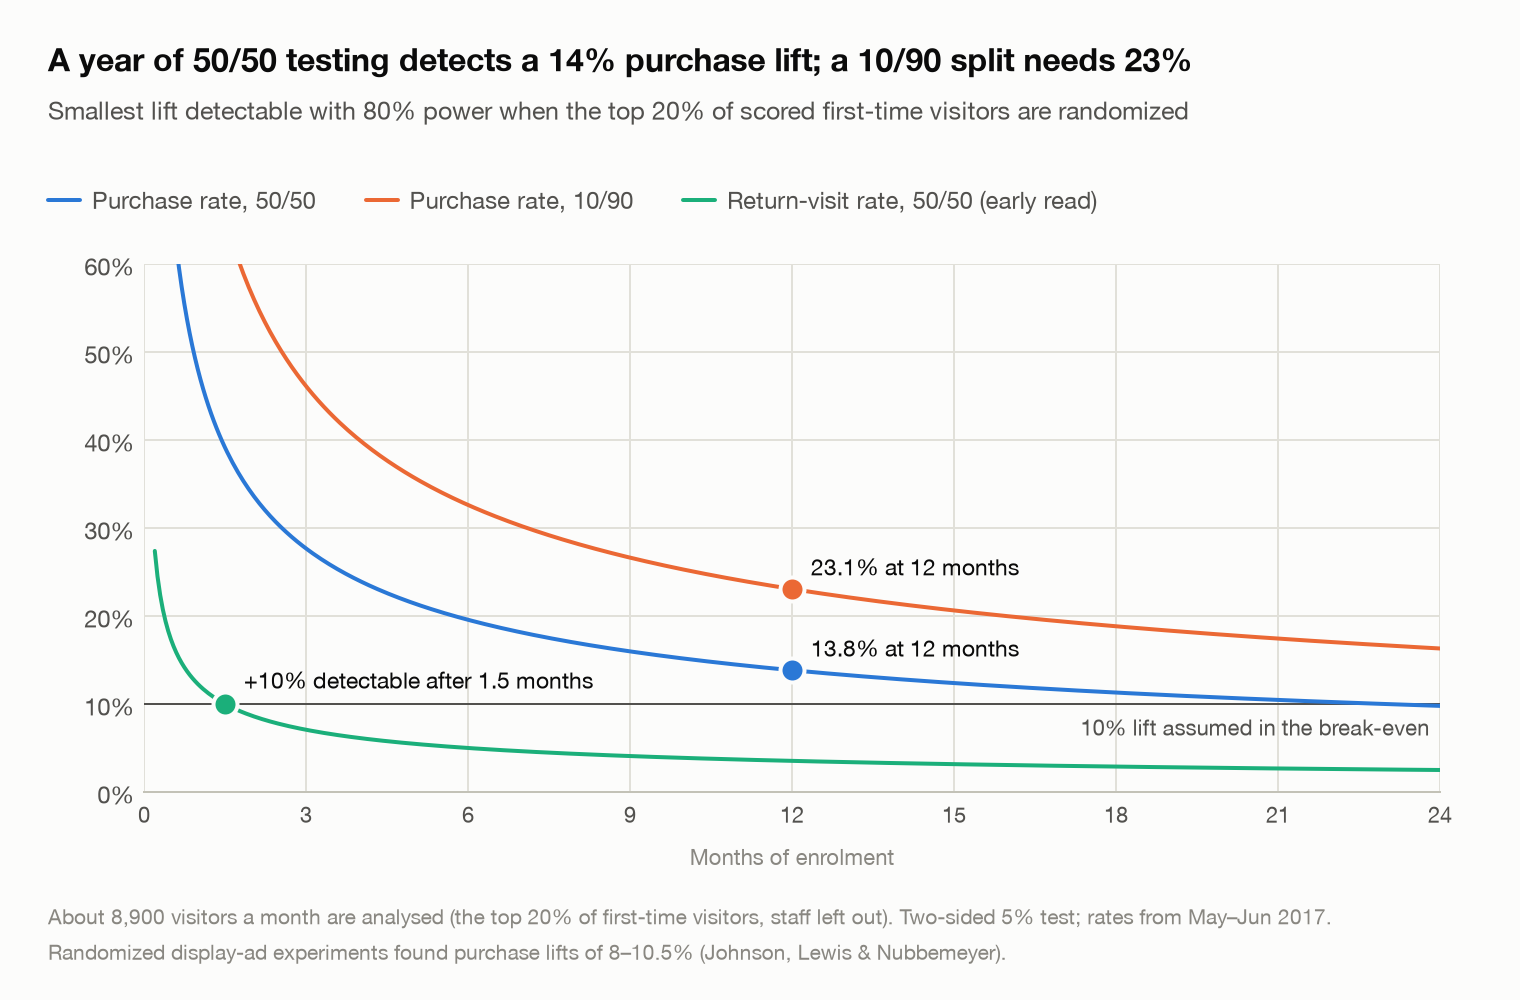

In [5]:
# Smallest detectable lift by months of enrolment (no viz helper draws this form, so it's drawn here in the same style)
m_axis = np.linspace(0.2, 24, 480)
p, r = top20.purchase_rate, top20.return_visit_rate
curves = {"Purchase rate, 50/50": (two_sample_mde(p, proportion_sd(p), per_month * m_axis, 0.5), viz.SERIES_1),
          "Purchase rate, 10/90": (two_sample_mde(p, proportion_sd(p), per_month * m_axis, 0.1), "#eb6834"),
          "Return-visit rate, 50/50 (early read)": (two_sample_mde(r, proportion_sd(r), per_month * m_axis, 0.5), "#1baf7a")}
at_12 = {split: two_sample_mde(p, proportion_sd(p), per_month * 12, h) for split, h in [("50/50", 0.5), ("10/90", 0.1)]}
early = duration_for_power(lambda m: two_sample_power(r, proportion_sd(r), LIFT, per_month * m, 0.5))

viz.apply_style()
fig, ax = viz.figure(760, 500, plot_box=(72, 132, 40, 104))
ax.set_xlim(0, 24)
ax.set_ylim(0, 0.6)
ax.set_xticks(range(0, 25, 3), [str(m) for m in range(0, 25, 3)])
ax.set_yticks(np.arange(0, 0.61, 0.1), [f"{t:.0%}" for t in np.arange(0, 0.61, 0.1)])
ax.grid(axis="both", zorder=0)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(viz.AXIS)
ax.set_xlabel("Months of enrolment", fontsize=viz.px(11), color=viz.MUTED, labelpad=6)
ax.axhline(LIFT, color=viz.INK_2, lw=viz.px(1), zorder=2)
ax.text(23.8, LIFT - 0.012, "10% lift assumed in the break-even", ha="right", va="top", fontsize=viz.px(11),
        color=viz.INK_2)
for label, (mde_curve, color) in curves.items():
    ax.plot(m_axis, mde_curve, color=color, lw=viz.px(2), solid_capstyle="round", solid_joinstyle="round", zorder=3)
for split, color in [("50/50", viz.SERIES_1), ("10/90", "#eb6834")]:
    viz.dot(ax, 12, at_12[split], color, diameter_px=8)
    ax.text(12.35, at_12[split] + 0.01, f"{at_12[split]:.1%} at 12 months", ha="left", va="bottom",
            fontsize=viz.px(11.5), color=viz.INK)
viz.dot(ax, early, LIFT, "#1baf7a", diameter_px=8)
ax.text(early + 0.35, LIFT + 0.012, f"+10% detectable after {early:.1f} months", ha="left", va="bottom",
        fontsize=viz.px(11.5), color=viz.INK)

viz.header(fig, f"A year of 50/50 testing detects a {at_12['50/50']:.0%} purchase lift; a 10/90 split needs "
                f"{at_12['10/90']:.0%}",
           "Smallest lift detectable with 80% power when the top 20% of scored first-time visitors are randomized")
w, h = fig.get_size_inches() * viz.PX_PER_IN
lx = 24
for label, (_, color) in curves.items():   # legend row under the subtitle
    fig.add_artist(Line2D([lx / w, (lx + 16) / w], [1 - 100 / h] * 2, color=color, lw=viz.px(2),
                          transform=fig.transFigure, solid_capstyle="round"))
    t = fig.text((lx + 22) / w, 1 - 100 / h, label, ha="left", va="center", fontsize=viz.px(12), color=viz.INK_2)
    fig.canvas.draw()
    lx += 22 + t.get_window_extent().width / (fig.dpi / viz.PX_PER_IN) + 26
viz.footnote(fig, f"About {round(per_month, -2):,.0f} visitors a month are analysed (the top 20% of first-time visitors, staff left out). "
                  "Two-sided 5% test; rates from May–Jun 2017.\nRandomized display-ad experiments found purchase lifts of "
                  "8–10.5% (Johnson, Lewis & Nubbemeyer).")
viz.show_saved(fig, ROOT / "reports/figures/test_retargeting_mde.png")

**Retargeting:**

- **A 10% holdout is badly underpowered.** At a +10% lift, a 10/90 split has 7% power after 6 weeks, 9% after 3 months, 14% after 6 months and 23% after 12 months. It would need about 5 years (64 months) to reach 80%.
- **Purchases need a 50/50 split and a year.** Twelve months of enrolment detect a lift of about 14% (13.8%) with 80% power. A +10% lift has only 53% power and would take about 23 months. A 13.8% lift is also the break-even lift at $0.145 per retargeted visitor, so a year settles the business question whenever the real cost is at or above that level.
- **Return visits give an early read.** A +10% lift in the 30-day return-visit rate is detectable after about 1.5 months at 50/50 (4 months at 10/90). That shows the ads reach people; it doesn't show they cause purchases.
- **Revenue can't be the metric.** Capped 30-day revenue is so skewed that a 12-month 50/50 test detects only lifts of about 29% or more; +10% would take more than 8 years (103 months).

## 2. Display holdout (D1)

The question is whether Display ads cause the purchases GA credits to them. Volumes come from 52 complete weeks of outside sessions (Aug 1, 2016 – Jul 30, 2017): purchases and visits GA labels **Display**, and the subset that are **fresh ad clicks** rather than return visits carrying Display's tag (`isTrueDirect`).

**The key account is left out** of both the store-wide and the Display volumes. Visitor 1957458976293878100 is now reported as its own segment (`src/segments.py`). Its purchases come from an existing corporate relationship, which a holdout of ad audiences wouldn't move, and it alone would add 15 GA-labelled Display purchases, all on return visits.

In [6]:
START = pd.Timestamp("2016-08-01")   # a Monday: 52 complete weeks to 2017-07-30
sessions = sessions.assign(week=(sessions.session_date - START).dt.days // 7)
key = sessions[is_key_account(sessions.full_visitor_id) & sessions.week.between(0, 51)]
key_display = key[key.channel.eq("Display")]
print(f"Left out, the key account: {len(key):,} visits and {int(key.purchased.sum())} purchases, of which "
      f"{int(key_display.purchased.sum())} GA-labelled Display ({int(key_display[key_display.is_true_direct.astype(bool)].purchased.sum())} "
      "on return visits)")
outside = sessions[~sessions.is_internal.astype(bool) & ~is_key_account(sessions.full_visitor_id)].query("0 <= week <= 51")
ga_label = outside.channel.eq("Display")
fresh = ga_label & ~outside.is_true_direct.astype(bool)
weekly = pd.DataFrame({
    ("purchases", "store-wide"): outside.groupby("week").purchased.sum(),
    ("purchases", "Display, GA label"): outside[ga_label].groupby("week").purchased.sum(),
    ("purchases", "Display, fresh ad clicks"): outside[fresh].groupby("week").purchased.sum(),
    ("sessions", "store-wide"): outside.groupby("week").size(),
    ("sessions", "Display, GA label"): outside[ga_label].groupby("week").size(),
    ("sessions", "Display, fresh ad clicks"): outside[fresh].groupby("week").size(),
}).reindex(range(52)).fillna(0)   # a week without any Display visit or purchase counts as zero
per_week = weekly.mean()

# Visitors who come back repeatedly make weekly counts noisier than Poisson. Variance-inflation factor per visitor,
# over the last 12 complete weeks: sum(c^2) / sum(c), where c is each visitor's count (1 for a pure Poisson process).
recent = outside[outside.week >= 40]
vif = {"purchases": (recent.groupby("full_visitor_id").purchased.sum() ** 2).sum() / recent.purchased.sum(),
       "sessions": (recent.groupby("full_visitor_id").size() ** 2).sum() / len(recent)}
print(f"variance inflation from repeat visitors: purchases {vif['purchases']:.2f}, sessions {vif['sessions']:.2f}")
pd.DataFrame({"per_week": per_week, "total_52_weeks": weekly.sum()}).style.format(
    {"per_week": "{:,.2f}", "total_52_weeks": "{:,.0f}"})

Left out, the key account: 275 visits and 16 purchases, of which 15 GA-labelled Display (15 on return visits)


variance inflation from repeat visitors: purchases 1.21, sessions 2.05


In [7]:
# Power to detect the loss if EVERY Display-credited purchase (or visit) were incremental: the largest effect possible
rows = []
for outcome in ["purchases", "sessions"]:
    store = per_week[(outcome, "store-wide")]
    for credited in ["Display, GA label", "Display, fresh ad clicks"]:
        lost = per_week[(outcome, credited)]
        for holdout in (0.10, 0.20, 0.50):
            row = {"outcome": outcome, "credited": credited, "holdout": f"{holdout:.0%}", "per_week": lost,
                   "share_of_store": lost / store}
            for weeks in (4, 6, 12):
                row[f"power_{weeks}_weeks"] = poisson_power(store, store - lost, weeks, holdout)
            row["power_12_weeks_with_repeats"] = poisson_power(store, store - lost, 12, holdout, vif=vif[outcome])
            row["weeks_for_80pct_with_repeats"] = duration_for_power(
                lambda w: poisson_power(store, store - lost, w, holdout, vif=vif[outcome]))
            rows.append(row)
display_power = pd.DataFrame(rows).set_index(["outcome", "credited", "holdout"])
display_power.style.format({"per_week": "{:,.2f}", "share_of_store": "{:.2%}", "power_4_weeks": "{:.1%}",
                            "power_6_weeks": "{:.1%}", "power_12_weeks": "{:.1%}", "power_12_weeks_with_repeats": "{:.1%}",
                            "weeks_for_80pct_with_repeats": "{:,.0f}"})

In [8]:
# The site-visit test, 50/50 for 12 weeks: store-wide MDE, and the largest randomized audience (visits a week) at which
# losing all Display-credited visits is detected with 80% power. Solves D W = z* sqrt(vif 2 W (2 S - D)) for S.
weeks, store = 12, per_week[("sessions", "store-wide")]
rows = []
for credited in ["Display, GA label", "Display, fresh ad clicks"]:
    lost = per_week[("sessions", credited)]
    for variance, v in [("Poisson", 1.0), ("with repeat visitors", vif["sessions"])]:
        largest = (lost ** 2 * weeks / (2 * z_star() ** 2 * v) + lost) / 2
        rows.append({"credited": credited, "variance": variance, "lost_per_week": lost,
                     "store_wide_power": poisson_power(store, store - lost, weeks, 0.5, vif=v),
                     "store_wide_mde_per_week": poisson_mde(store, weeks, 0.5, vif=v),
                     "largest_audience_per_week": largest, "largest_share_of_outside_visits": largest / store,
                     "power_at_largest": poisson_power(largest, largest - lost, weeks, 0.5, vif=v)})
visits_test = pd.DataFrame(rows).set_index(["credited", "variance"])
visits_test.style.format({"lost_per_week": "{:,.1f}", "store_wide_power": "{:.1%}", "store_wide_mde_per_week": "{:,.0f}",
                          "largest_audience_per_week": "{:,.0f}", "largest_share_of_outside_visits": "{:.1%}",
                          "power_at_largest": "{:.1%}"})

**Display:**

- **A purchase-based holdout can't work at this store's volume.** Without the key account, Display is credited with 2.15 purchases a week (1.27 from fresh ad clicks) out of 117 store-wide. Even if every one were incremental, a 10%, 20% or 50% holdout run for 4 to 12 weeks has 5.1–6.4% power, barely above the 5% that chance alone gives. Reaching 80% would take at least 18 years (952 weeks, allowing for repeat buyers).
- **Site visits are the measurable outcome.** Display is credited with 103 visits a week (78 of them fresh ad clicks). A 50/50 split for 12 weeks detects the loss of all 103 with 30% power store-wide, or 17% allowing for repeat visitors. It reaches 80% power only if the randomized audience makes at most about 2,000 visits a week (13% of outside traffic, allowing for repeat visitors; about 4,100 under a pure Poisson model), for example the users in Display's own audience lists rather than every site visitor.

## 3. Recommended designs

In [9]:
p50 = retargeting.loc[("30-day purchase rate", "50/50")]
ret50 = retargeting.loc[("30-day return-visit rate", "50/50")]
ga = visits_test.loc[("Display, GA label", "with repeat visitors")]
designs = pd.DataFrame({
    "Retargeting (D2)": {
        "Randomize": "First-time visitors scored into the top 20%, by visitor ID, at scoring time (before any ad)",
        "Primary metric": ("30-day purchase rate per assigned visitor (intention to treat), with staff identified "
                           "afterwards left out. Early read: 30-day return-visit rate"),
        "Split": "50/50 (retargeted / held out)",
        "Duration": "12 months of enrolment, read 30 days after it closes",
        "MDE (80% power)": (f"{p50.mde_12_months:.1%} relative lift in purchases ({p50.power_12_months:.0%} power at +10%); "
                            f"+10% in return visits after {ret50.months_for_80pct:.1f} months"),
        "Decision rule": (f"Break-even lift = cost per retargeted visitor ÷ (${revenue_per_visitor:.2f} × 50% margin). "
                          "Keep retargeting if the purchase lift's 95% CI lies above it, stop if the CI lies below it, "
                          f"otherwise extend enrolment (about {p50.months_for_80pct:.0f} months gives 80% power at +10%). "
                          "Early read: if return visits aren't clearly up, fix ad delivery before waiting a year. "
                          "After the decision, keep a 10% holdout to monitor"),
    },
    "Display (D1)": {
        "Randomize": "Users in the audiences Display campaigns target, split by the ad platform per user (not by region)",
        "Primary metric": ("Site visits per assigned user, by any route. Purchases and revenue reported but not "
                           "powered"),
        "Split": "50/50 (shown ads / held out)",
        "Duration": "12 weeks",
        "MDE (80% power)": (f"The loss of all {ga.lost_per_week:.0f} Display-credited visits a week, if the audience makes "
                            f"at most {ga.largest_audience_per_week:,.0f} visits a week (store-wide power "
                            f"{ga.store_wide_power:.0%})"),
        "Decision rule": ("If held-out users make significantly fewer visits, Display adds traffic: value the extra "
                          "visits at the store's revenue per visit and compare with Display's cost. If the difference's "
                          "95% CI stays below the visits GA credits to Display, GA over-credits it: budget Display on "
                          "the measured difference, not on GA's report"),
    },
})
designs.style.set_properties(**{"text-align": "left", "white-space": "normal"})

,Retargeting (D2),Display (D1)
Randomize,"First-time visitors scored into the top 20%, by visitor ID, at scoring time (before any ad)","Users in the audiences Display campaigns target, split by the ad platform per user (not by region)"
Primary metric,"30-day purchase rate per assigned visitor (intention to treat), with staff identified afterwards left out. Early read: 30-day return-visit rate","Site visits per assigned user, by any route. Purchases and revenue reported but not powered"
Split,50/50 (retargeted / held out),50/50 (shown ads / held out)
Duration,"12 months of enrolment, read 30 days after it closes",12 weeks
MDE (80% power),13.8% relative lift in purchases (53% power at +10%); +10% in return visits after 1.5 months,"The loss of all 103 Display-credited visits a week, if the audience makes at most 2,044 visits a week (store-wide power 17%)"
Decision rule,"Break-even lift = cost per retargeted visitor ÷ ($2.10 × 50% margin). Keep retargeting if the purchase lift's 95% CI lies above it, stop if the CI lies below it, otherwise extend enrolment (about 23 months gives 80% power at +10%). Early read: if return visits aren't clearly up, fix ad delivery before waiting a year. After the decision, keep a 10% holdout to monitor","If held-out users make significantly fewer visits, Display adds traffic: value the extra visits at the store's revenue per visit and compare with Display's cost. If the difference's 95% CI stays below the visits GA credits to Display, GA over-credits it: budget Display on the measured difference, not on GA's report"
